In [4]:
print("Hello, World!")


Hello, World!


In [10]:
pip install opencv-python matplotlib 


Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install ucimlrepo 

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip list

Package                        Version
------------------------------ --------------
absl-py                        2.2.1
annotated-types                0.7.0
anyio                          4.11.0
appdirs                        1.4.4
argcomplete                    3.6.2
argon2-cffi                    25.1.0
argon2-cffi-bindings           25.1.0
arrow                          1.3.0
asgiref                        3.9.1
asttokens                      3.0.0
astunparse                     1.6.3
async-lru                      2.0.5
attr                           0.3.1
attrs                          25.4.0
azure-core                     1.35.0
azure-storage-blob             12.26.0
babel                          2.17.0
beautifulsoup4                 4.14.2
black                          25.1.0
bleach                         5.0.1
blinker                        1.9.0
boto                           2.49.0
boto3                          1.40.15
botocore                       1.40.15
branca      

In [1]:

import tensorflow as tf
import os   #manage files 

In [3]:
cpu=tf.config.experimental.list_physical_devices('CPU')

In [8]:
tf.config.list_physical_devices('CPU')

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import os

# Dataset path and parameters

In [9]:
train_dir = 'Jute_Pest_Dataset/train'
val_dir = 'Jute_Pest_Dataset/val'
test_dir = 'Jute_Pest_Dataset/test'

IMG_HEIGHT, IMG_WIDTH = 64, 64
BATCH_SIZE = 32
EPOCHS =30


# Data Generators

In [10]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_datagen = ImageDataGenerator(
    rescale=1./255,            # normalize pixel values
    rotation_range=30,         # random rotation up to 30°
    zoom_range=0.3,            # random zoom up to 30%
    shear_range=0.25,          # random shearing
    width_shift_range=0.25,    # horizontal shift
    height_shift_range=0.25,   # vertical shift
    horizontal_flip=True,      # random left-right flips
    vertical_flip=True,        # random up-down flips
    fill_mode='nearest'        # fill missing pixels after transformation
)

# No augmentation for validation/test sets — only rescaling
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
class_labels = list(train_generator.class_indices.keys())
print("Number of classes:", num_classes)


Found 6443 images belonging to 17 classes.
Found 413 images belonging to 17 classes.
Found 379 images belonging to 17 classes.
Number of classes: 17


In [12]:
class_labels

['Beet Armyworm',
 'Black Hairy',
 'Cutworm',
 'Field Cricket',
 'Jute Aphid',
 'Jute Hairy',
 'Jute Red Mite',
 'Jute Semilooper',
 'Jute Stem Girdler',
 'Jute Stem Weevil',
 'Leaf Beetle',
 'Mealybug',
 'Pod Borer',
 'Scopula Emissaria',
 'Termite',
 'Termite odontotermes (Rambur)',
 'Yellow Mite']

# Build a Simple CNN

In [159]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_95 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_102         │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_80 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_103         │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_81 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_104         │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_82 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_105         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,801 (2.62 MB)

 Trainable params: 686,097 (2.62 MB)

 Non-trainable params: 704 (2.75 KB)

# Train on Training Set

In [160]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Callback to reduce learning rate if validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # metric to monitor
    factor=0.5,           # reduce LR by half
    patience=5,           # wait 5 epochs without improvement
    min_lr=1e-6           # minimum learning rate
)

# Optional: early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model with callbacks
history = model.fit(
    train_generator,
    validation_data=val_generator,  # must include validation data
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[reduce_lr, early_stop]  # <-- include here
)


Epoch 1/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 33s 157ms/step - accuracy: 0.1671 - loss: 3.1977 - val_accuracy: 0.1235 - val_loss: 3.1220 - learning_rate: 0.0010
Epoch 2/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 53s 262ms/step - accuracy: 0.2940 - loss: 2.3536 - val_accuracy: 0.2494 - val_loss: 2.6217 - learning_rate: 0.0010
Epoch 3/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 47s 232ms/step - accuracy: 0.3700 - loss: 2.0422 - val_accuracy: 0.3099 - val_loss: 2.2652 - learning_rate: 0.0010
Epoch 4/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 57s 284ms/step - accuracy: 0.4151 - loss: 1.8599 - val_accuracy: 0.3487 - val_loss: 2.2479 - learning_rate: 0.0010
Epoch 5/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 76s 255ms/step - accuracy: 0.4770 - loss: 1.6531 - val_accuracy: 0.4722 - val_loss: 1.8983 - learning_rate: 0.0010
Epoch 6/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 63s 312ms/step - accuracy: 0.5030 - loss: 1.5703 - val_accuracy: 0.4479 - val_loss: 1.8673 - learning_rate: 0.0010
Epoch 7/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 50s 248ms/step - accuracy: 0.5

# Evaluate on Validation Set

In [161]:
val_loss, val_acc = model.evaluate(val_generator)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5440 - loss: 1.7927
Validation Loss: 1.4415326118469238
Validation Accuracy: 0.6731234788894653


# Evaluate on Test Set

In [168]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7271 - loss: 1.1583
Test Loss: 0.9477273225784302
Test Accuracy: 0.7757256031036377


# Confusion Matrix & Classification Report

In [163]:
y_true_test = test_generator.classes
y_pred_test = np.argmax(model.predict(test_generator), axis=1)

print("\nTest Confusion Matrix:\n", confusion_matrix(y_true_test, y_pred_test))
print("\nTest Classification Report:\n", classification_report(
    y_true_test, y_pred_test, target_names=class_labels
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

Test Confusion Matrix:
 [[ 9  0  2  1  1  0  0  0  0  5  0  1  0  0  0  1  0]
 [ 0 16  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 2  2 10  2  0  0  0  0  0  2  0  1  0  0  0  0  1]
 [ 0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 20  0  0  0  0  0  0  0  1  0  0  0  1]
 [ 0  0  0  0  0 18  0  0  0  0  0  1  0  0  0  0  1]
 [ 0  0  0  0  0  0 23  0  0  0  0  1  0  0  0  0  0]
 [ 1  0  0  0  0 16  0  4  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  3  0  0  0  0 21  0  0  0  0  0  0  0  0]
 [ 2  0  1  4  0  1  1  0  0 15  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 24  0  0  0  0  0  0]
 [ 0  0  1  2  3  1  3  0  0  0  0 14  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 24  0  0  0  0]
 [ 0  0  0  0  0  2  5  0  0  1  0  1  0 15  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  1  2  0 14  3  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 24  0]
 [ 0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0 23]]

Test Classifica

# Plot Accuracy & Loss

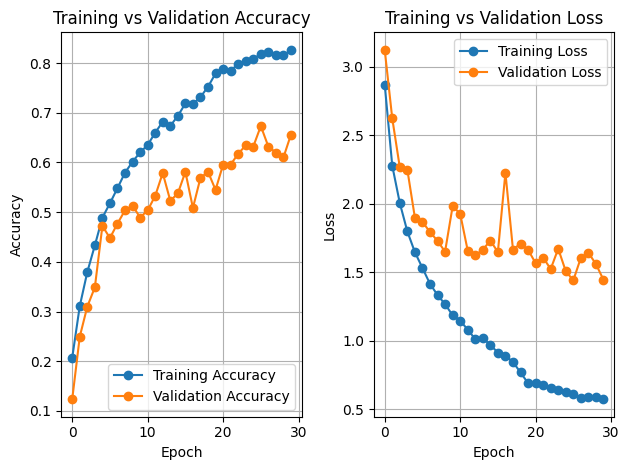

In [164]:
# ----------- Plot Accuracy -----------
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ----------- Plot Loss -----------
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Predict a Single Image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted Class: Yellow Mite
Prediction Probabilities: [[1.8811674e-04 2.0671319e-10 6.3438982e-08 7.0208196e-05 7.6232455e-03
  3.0721691e-05 2.7243998e-06 3.3479158e-10 8.6489917e-09 1.2683840e-06
  8.1738366e-11 3.5765680e-08 4.1774879e-11 7.1998982e-12 1.2111115e-09
  3.8625794e-07 9.9208307e-01]]


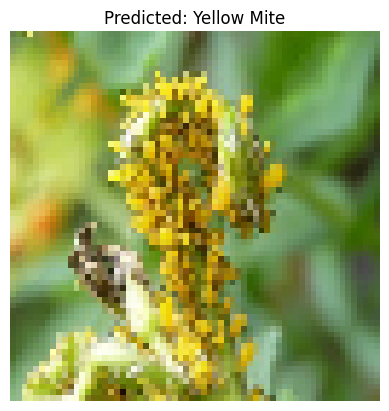

In [15]:
def predict_image(model, img_path):
    """
    Predict the class of a single image using the trained model.
    """
    # Load and resize image
    img = load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    
    # Convert to array and normalize
    img_array = img_to_array(img) / 255.0
    
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    
    # Make prediction
    pred = model.predict(img_array)
    class_index = np.argmax(pred)
    class_label = class_labels[class_index]
    
    # Print result
    print(f"Predicted Class: {class_label}")
    print(f"Prediction Probabilities: {pred}")
    
    # Display image
    plt.imshow(img)
    plt.title(f'Predicted: {class_label}')
    plt.axis('off')
    plt.show()

# ==========================
# Example Usage: Predict a given image
# ==========================
image_path = r"Jute_Pest_Dataset\test\Yellow Mite\yellow_mite_0_6265.jpg"
predict_image(model, image_path)

# Save the model

In [169]:
# Save the entire model (architecture + weights + optimizer state)
model.save("plastic_sorting_model_2.h5")
print("Model saved successfully as 'plastic_sorting_model.h5'")


Model saved successfully as 'plastic_sorting_model.h5'


# Load the model

In [12]:
from tensorflow.keras.models import load_model
from tensorflow.keras import optimizers
import tensorflow as tf
tf.compat.v1.enable_eager_execution()
print("Eager execution enabled:", tf.executing_eagerly())

# Load the model
model = load_model("plastic_sorting_model_2.h5")
print("Model loaded successfully!")


Eager execution enabled: True
Model loaded successfully!


# Compare all optimizer performances

Eager execution: True
Epoch 1/20


c:\Users\RAVINDU MALSHAN\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


202/202 ━━━━━━━━━━━━━━━━━━━━ 54s 268ms/step - accuracy: 0.7877 - loss: 0.6982 - val_accuracy: 0.5036 - val_loss: 2.0254
Epoch 2/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 54s 267ms/step - accuracy: 0.7688 - loss: 0.7349 - val_accuracy: 0.5932 - val_loss: 1.7082
Epoch 3/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 54s 268ms/step - accuracy: 0.7766 - loss: 0.6895 - val_accuracy: 0.5932 - val_loss: 1.6583
Epoch 4/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 55s 272ms/step - accuracy: 0.7923 - loss: 0.6752 - val_accuracy: 0.5763 - val_loss: 1.8636
Epoch 5/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 56s 276ms/step - accuracy: 0.8071 - loss: 0.6357 - val_accuracy: 0.5400 - val_loss: 1.9693
Epoch 6/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 55s 274ms/step - accuracy: 0.7941 - loss: 0.6736 - val_accuracy: 0.6562 - val_loss: 1.4341
Epoch 7/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 55s 272ms/step - accuracy: 0.7915 - loss: 0.6618 - val_accuracy: 0.6538 - val_loss: 1.4568
Epoch 8/20
202/202 ━━━━━━━━━━━━━━━━━━━━ 56s 275ms/step - accuracy: 0.8089 - loss: 0.6141 - val

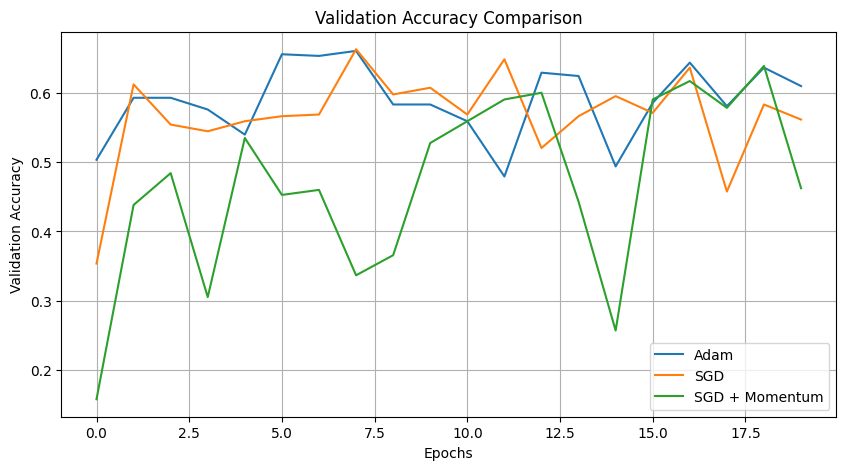

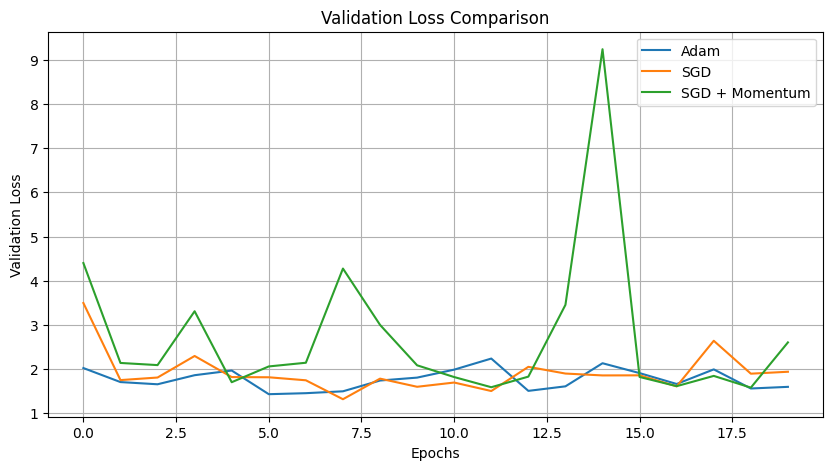

In [30]:
import tensorflow as tf
from tensorflow.keras import models, optimizers
import matplotlib.pyplot as plt

# Ensure eager mode (needed for fine-tuning)
tf.config.run_functions_eagerly(True)
print("Eager execution:", tf.executing_eagerly())

# Load your already-trained Adam model
base_model = models.load_model("plastic_sorting_model_2.h5")

# Helper function to recompile models with new optimizer
def recompile_with_optimizer(base_model, optimizer):
    new_model = models.clone_model(base_model)
    new_model.set_weights(base_model.get_weights())
    new_model.compile(optimizer=optimizer,
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])
    return new_model

# Define three versions with different optimizers
model_adam = recompile_with_optimizer(base_model, optimizers.Adam(learning_rate=0.001))
model_sgd = recompile_with_optimizer(base_model, optimizers.SGD(learning_rate=0.01))
model_sgd_momentum = recompile_with_optimizer(base_model, optimizers.SGD(learning_rate=0.01, momentum=0.9))

# Fine-tune each model for a few epochs (e.g., 5–10)
epochs = 20
history_adam = model_adam.fit(train_generator, validation_data=val_generator, epochs=epochs)
history_sgd = model_sgd.fit(train_generator, validation_data=val_generator, epochs=epochs)
history_sgd_momentum = model_sgd_momentum.fit(train_generator, validation_data=val_generator, epochs=epochs)

# Evaluate all models on validation data
adam_eval = model_adam.evaluate(val_generator, verbose=0)
sgd_eval = model_sgd.evaluate(val_generator, verbose=0)
momentum_eval = model_sgd_momentum.evaluate(val_generator, verbose=0)

# Print comparison results
print("\n--- Optimizer Comparison Results ---")
print(f"Adam:           Loss = {adam_eval[0]:.4f}, Accuracy = {adam_eval[1]*100:.2f}%")
print(f"SGD:            Loss = {sgd_eval[0]:.4f}, Accuracy = {sgd_eval[1]*100:.2f}%")
print(f"SGD+Momentum:   Loss = {momentum_eval[0]:.4f}, Accuracy = {momentum_eval[1]*100:.2f}%")

# Plot accuracy comparison
plt.figure(figsize=(10,5))
plt.plot(history_adam.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_sgd_momentum.history['val_accuracy'], label='SGD + Momentum')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot loss comparison
plt.figure(figsize=(10,5))
plt.plot(history_adam.history['val_loss'], label='Adam')
plt.plot(history_sgd.history['val_loss'], label='SGD')
plt.plot(history_sgd_momentum.history['val_loss'], label='SGD + Momentum')
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# save models

In [34]:
# --- Save all fine-tuned models ---
model_adam.save("plastic_sorting_model_adam_finetuned.h5")
model_sgd.save("plastic_sorting_model_sgd_finetuned.h5")
model_sgd_momentum.save("plastic_sorting_model_sgd_momentum_finetuned.h5")
print("\n✅ All fine-tuned models have been saved successfully!")


✅ All fine-tuned models have been saved successfully!


# plots

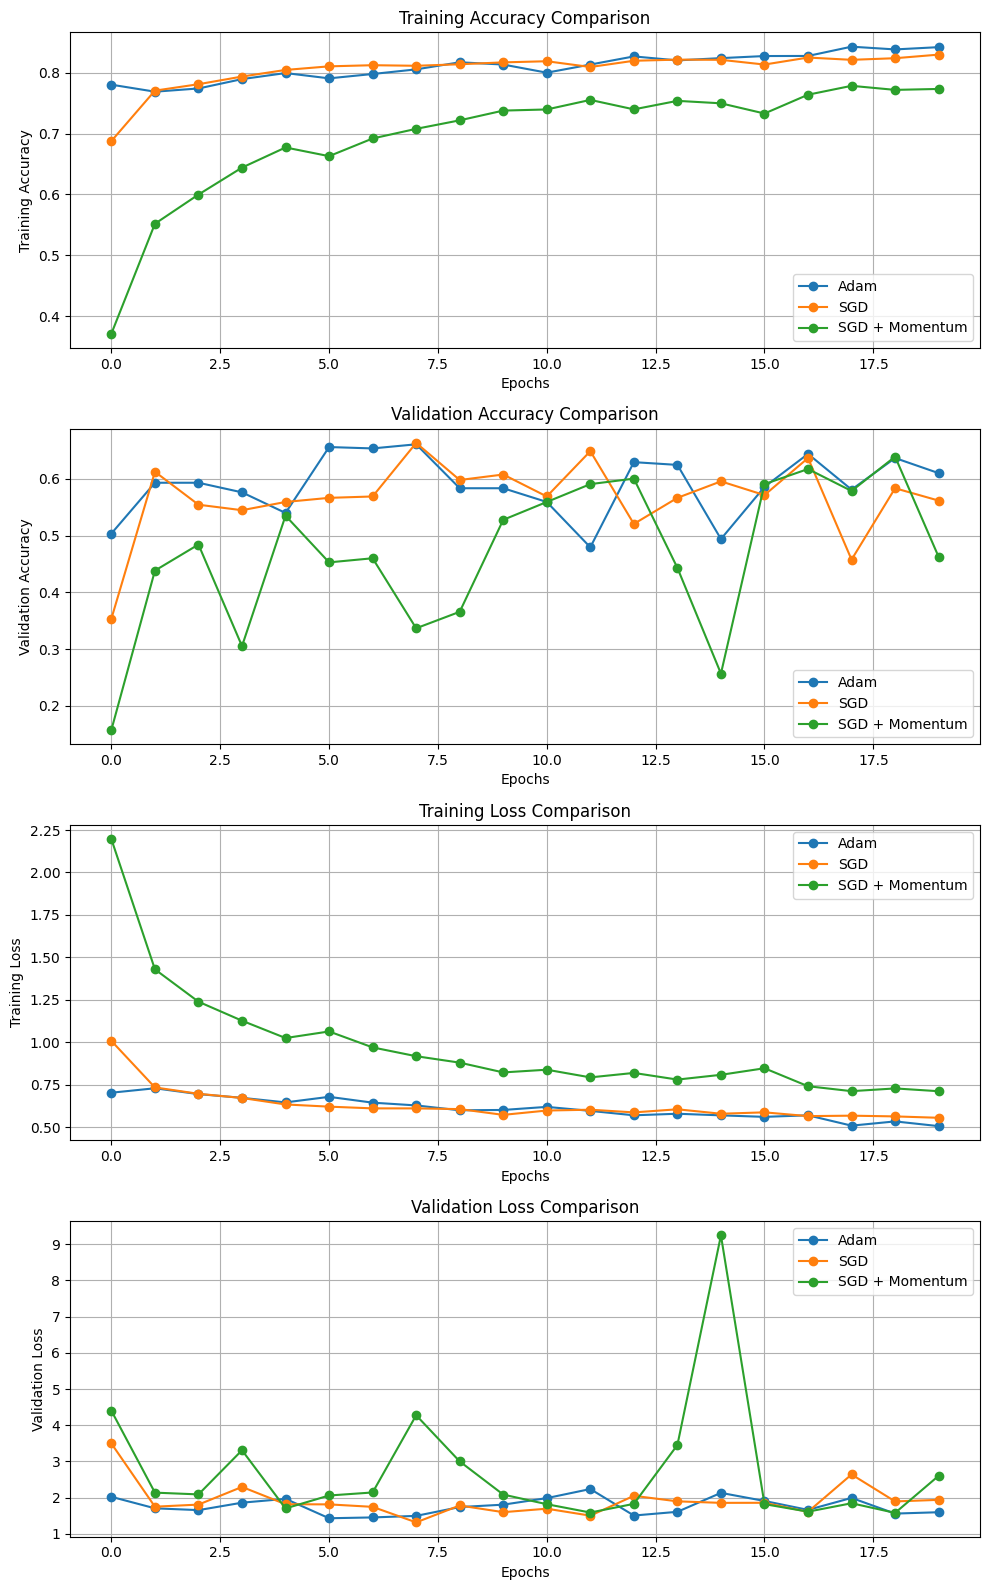

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 16))

# --- 1️⃣ Training Accuracy ---
plt.subplot(4, 1, 1)
plt.plot(history_adam.history['accuracy'], 'o-', label='Adam')
plt.plot(history_sgd.history['accuracy'], 'o-', label='SGD')
plt.plot(history_sgd_momentum.history['accuracy'], 'o-', label='SGD + Momentum')
plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Training Accuracy")
plt.legend()
plt.grid(True)

# --- 2️⃣ Validation Accuracy ---
plt.subplot(4, 1, 2)
plt.plot(history_adam.history['val_accuracy'], 'o-', label='Adam')
plt.plot(history_sgd.history['val_accuracy'], 'o-', label='SGD')
plt.plot(history_sgd_momentum.history['val_accuracy'], 'o-', label='SGD + Momentum')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)

# --- 3️⃣ Training Loss ---
plt.subplot(4, 1, 3)
plt.plot(history_adam.history['loss'], 'o-', label='Adam')
plt.plot(history_sgd.history['loss'], 'o-', label='SGD')
plt.plot(history_sgd_momentum.history['loss'], 'o-', label='SGD + Momentum')
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)

# --- 4️⃣ Validation Loss ---
plt.subplot(4, 1, 4)
plt.plot(history_adam.history['val_loss'], 'o-', label='Adam')
plt.plot(history_sgd.history['val_loss'], 'o-', label='SGD')
plt.plot(history_sgd_momentum.history['val_loss'], 'o-', label='SGD + Momentum')
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# model evaluations

In [31]:
from sklearn.metrics import classification_report
import numpy as np

# Utility: get predictions and true labels
def evaluate_classification_metrics(model, generator):
    y_true = generator.classes
    y_pred_probs = model.predict(generator)
    y_pred = np.argmax(y_pred_probs, axis=1)
    labels = list(generator.class_indices.keys())
    report = classification_report(y_true, y_pred, target_names=labels, digits=4, output_dict=True)
    return report

# Evaluate all models
report_adam = evaluate_classification_metrics(model_adam, val_generator)
report_sgd = evaluate_classification_metrics(model_sgd, val_generator)
report_sgd_momentum = evaluate_classification_metrics(model_sgd_momentum, val_generator)

# Print summary metrics
def print_summary(name, report):
    precision = report['weighted avg']['precision']
    recall = report['weighted avg']['recall']
    f1 = report['weighted avg']['f1-score']
    accuracy = report['accuracy']
    print(f"\n{name} Optimizer:")
    print(f"  Accuracy:  {accuracy*100:.2f}%")
    print(f"  Precision: {precision*100:.2f}%")
    print(f"  Recall:    {recall*100:.2f}%")
    print(f"  F1-Score:  {f1*100:.2f}%")

print_summary("Adam", report_adam)
print_summary("SGD", report_sgd)
print_summary("SGD + Momentum", report_sgd_momentum)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step


c:\Users\RAVINDU MALSHAN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RAVINDU MALSHAN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RAVINDU MALSHAN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step


c:\Users\RAVINDU MALSHAN\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step

Adam Optimizer:
  Accuracy:  61.02%
  Precision: 68.85%
  Recall:    61.02%
  F1-Score:  62.59%

SGD Optimizer:
  Accuracy:  56.17%
  Precision: 66.04%
  Recall:    56.17%
  F1-Score:  56.52%

SGD + Momentum Optimizer:
  Accuracy:  46.25%
  Precision: 54.17%
  Recall:    46.25%
  F1-Score:  46.48%


c:\Users\RAVINDU MALSHAN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RAVINDU MALSHAN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\RAVINDU MALSHAN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 